In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 윈도우 맑은 고딕 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [2]:
base_path = r"C:\kdt_0900_osh\data_analysis\resource\dataset"
file_name = r"hr_employee_attrition.csv"

file_path = os.path.join(base_path, file_name)

hr_df = pd.read_csv(file_path)
hr_df

,Attrition,Age,Gender,MaritalStatus,Education,Department,JobRole,BusinessTravel,OverTime,DistanceFromHome,MonthlyIncome,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,YearsAtCompany,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,PerformanceRating,YearsSinceLastPromotion
0,Yes,41,Female,Single,2,Sales,Sales Executive,Travel_Rarely,Yes,1,5993,11,0,8,6,2,4,1,3,0
1,No,49,Male,Married,1,Research & Development,Research Scientist,Travel_Frequently,No,8,5130,23,1,10,10,3,2,3,4,1
2,Yes,37,Male,Single,2,Research & Development,Laboratory Technician,Travel_Rarely,Yes,2,2090,15,0,7,0,4,3,3,3,0
3,No,33,Female,Married,4,Research & Development,Research Scientist,Travel_Frequently,Yes,3,2909,11,0,8,8,4,3,3,3,3
4,No,27,Male,Married,1,Research & Development,Laboratory Technician,Travel_Rarely,No,2,3468,12,1,6,2,1,2,3,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,No,36,Male,Married,2,Research & Development,Laboratory Technician,Travel_Frequently,No,23,2571,17,1,17,5,3,4,3,3,0
1466,No,39,Male,Married,1,Research & Development,Healthcare Representative,Travel_Rarely,No,6,9991,15,1,9,7,4,1,3,3,1
1467,No,27,Male,Married,3,Research & Development,Manufacturing Director,Travel_Rarely,Yes,4,6142,20,1,6,6,2,2,3,4,0
1468,No,49,Male,Married,3,Sales,Sales Executive,Travel_Frequently,No,2,5390,14,0,17,9,4,2,2,3,0


In [3]:
# 야근(OverTime)을 하는 직원과 야근을 하지 않는 직원의 이직률 차이가 얼마나 나는지 비교하고 결과를 서술하세요.

In [52]:
overtime_attrition = pd.crosstab(hr_df["OverTime"],hr_df["Attrition"],normalize="index")
overtime_attrition

Attrition,No,Yes
OverTime,,
No,0.895636,0.104364
Yes,0.694712,0.305288


<Axes: xlabel='OverTime'>

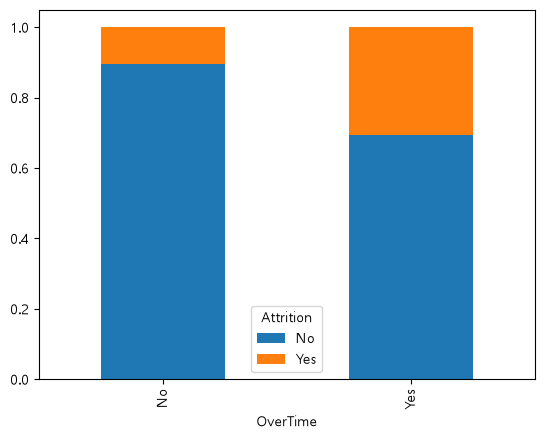

In [53]:
overtime_attrition.plot(kind="bar",stacked=True)

(0.0, 0.5)

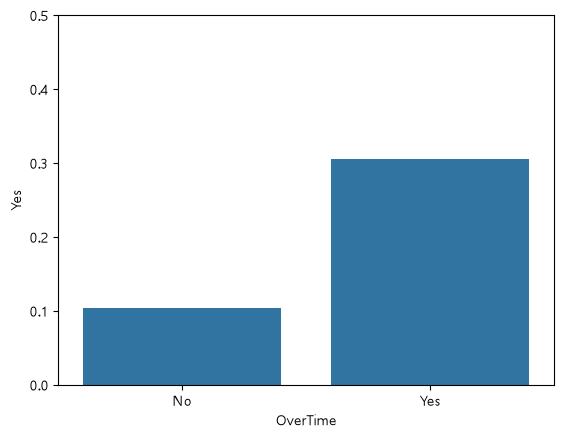

In [65]:
sns.barplot(data=overtime_attrition, x="OverTime", y="Yes")
plt.ylim(0,0.5)

In [25]:
overtime_attrition = hr_df.groupby("OverTime")["Attrition"].agg(
    att_yes = lambda x: (x == "Yes").sum() / x.count(),
    att_no = lambda x: (x == "No").sum() / x.count()
)
overtime_attrition

,att_yes,att_no
OverTime,,
No,0.104364,0.895636
Yes,0.305288,0.694712


<Axes: xlabel='OverTime'>

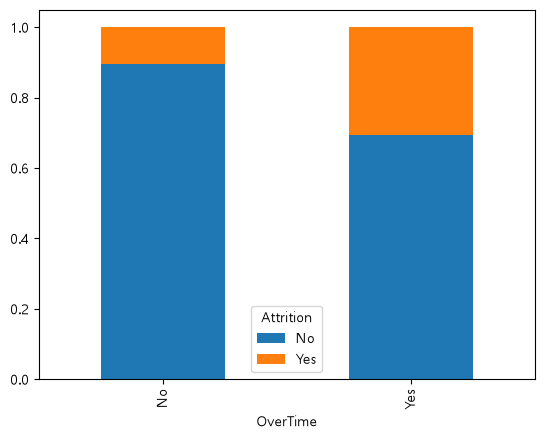

In [13]:
overtime_attrition.plot(kind="bar",stacked=True)

In [ ]:
overtime_attrition = hr_df.groupby("OverTime")["Attrition"].agg(
    att_yes = lambda x: (x == "Yes").sum() / x.count(),
    att_no = lambda x: (x == "No").sum() / x.count()
)
overtime_attrition

In [77]:
hr_df["YearsSinceLastPromotion"]

0       0
1       1
2       0
3       3
4       2
       ..
1465    0
1466    1
1467    0
1468    0
1469    1
Name: YearsSinceLastPromotion, Length: 1470, dtype: int64

In [14]:
# 이직한 직원(Attrition = Yes)과 잔류한 직원(No)의 월소득(MonthlyIncome) 평균 및 분포 차이 비교

In [16]:
hr_df.groupby("Attrition")["MonthlyIncome"].agg("mean")

Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64

<Axes: xlabel='Attrition', ylabel='MonthlyIncome'>

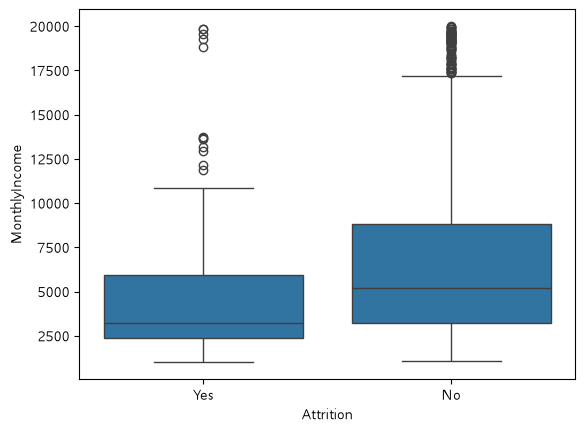

In [19]:
sns.boxplot(data=hr_df, x="Attrition", y="MonthlyIncome")

In [30]:
# 가설: 마지막 승진 후 기간(YearsSinceLastPromotion)이 길어질수록 이직률이 더 높아질까?

In [97]:
promo_attrition = hr_df.groupby("YearsSinceLastPromotion")["Attrition"].agg(
    att_yes = lambda x: (x == "Yes").sum() / x.count(),
    att_no = lambda x: (x == "No").sum() / x.count()
)
promo_attrition

,att_yes,att_no
YearsSinceLastPromotion,,
0,0.189329,0.810671
1,0.137255,0.862745
2,0.169811,0.830189
3,0.173077,0.826923
4,0.081967,0.918033
5,0.044444,0.955556
6,0.187500,0.812500
7,0.210526,0.789474
8,0.000000,1.000000


(0.0, 1.0)

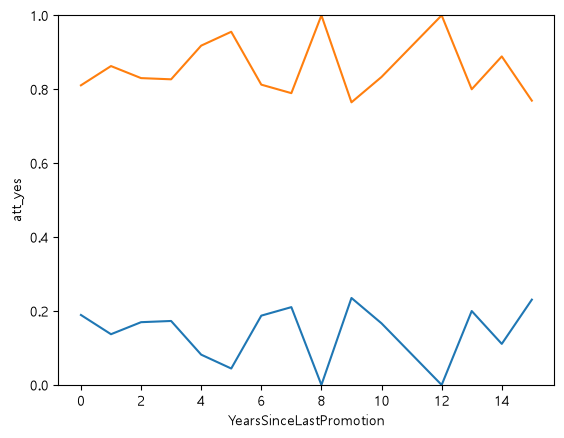

In [94]:
sns.lineplot(data=promo_attrition, x="YearsSinceLastPromotion", y="att_yes")
sns.lineplot(data=promo_attrition, x="YearsSinceLastPromotion", y="att_no")
plt.ylim(0,1)

In [95]:
hr_df.groupby("YearsSinceLastPromotion")["Attrition"].apply(lambda x: x.count())

YearsSinceLastPromotion
0     581
1     357
2     159
3      52
4      61
5      45
6      32
7      76
8      18
9      17
10      6
11     24
12     10
13     10
14      9
15     13
Name: Attrition, dtype: int64

In [101]:
bins=[-0.1,3,6,9,12,16]

hr_df["PromotionCut"] = pd.cut(hr_df["YearsSinceLastPromotion"], bins=bins)

promo_attrition = hr_df.groupby("PromotionCut")["Attrition"].agg(
    att_yes = lambda x: (x == "Yes").sum() / x.count(),
    att_no = lambda x: (x == "No").sum() / x.count()
)
promo_attrition

,att_yes,att_no
PromotionCut,,
"(-0.1, 3.0]",0.169713,0.830287
"(3.0, 6.0]",0.094203,0.905797
"(6.0, 9.0]",0.180180,0.819820
"(9.0, 12.0]",0.075000,0.925000
"(12.0, 16.0]",0.187500,0.812500


In [ ]:
sns.lineplot

In [88]:
# 워라밸 만족도(WorkLifeBalance) 1~4점 점수별 이직률 구하고, 워라밸 1점의 이직 위험도를 분석하기
wlb_attrition = pd.crosstab(hr_df["WorkLifeBalance"],hr_df["Attrition"],normalize="index") * 100
wlb_attrition

Attrition,No,Yes
WorkLifeBalance,,
1,68.750000,31.250000
2,83.139535,16.860465
3,85.778275,14.221725
4,82.352941,17.647059


In [89]:
pd.crosstab(hr_df["WorkLifeBalance"],hr_df["Attrition"])

Attrition,No,Yes
WorkLifeBalance,,
1,55,25
2,286,58
3,766,127
4,126,27


(0.0, 50.0)

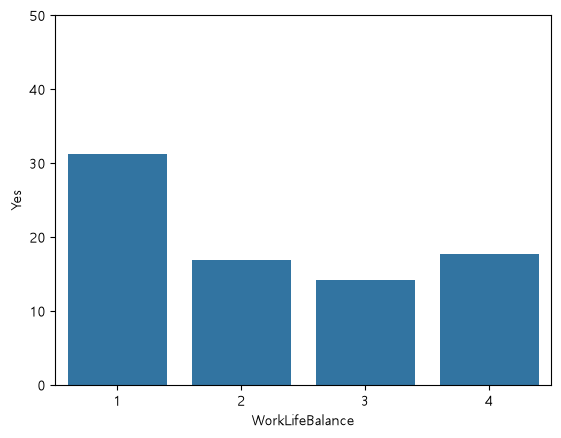

In [92]:
sns.barplot(wlb_attrition,x="WorkLifeBalance",y="Yes")
plt.ylim(0,50)